In [1]:
from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.util.termination_criterion import StoppingByEvaluations

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

class RandomForestOverfitProblem(FloatProblem):

    def __init__(self):
        super().__init__()

        # Variables: [n_estimators, max_depth, min_samples_split, criterion]
        self.lower_bound = [10,  1,  2, 0]
        self.upper_bound = [200, 20, 20, 1]

        self.data = load_breast_cancer()

    def number_of_variables(self):
        return 4

    def number_of_objectives(self):
        return 2

    def number_of_constraints(self):
        return 0

    def evaluate(self, solution):
        n_estimators      = max(10, int(round(solution.variables[0])))
        max_depth         = max(1,  int(round(solution.variables[1])))
        min_samples_split = max(2,  int(round(solution.variables[2])))
        criterion         = "gini" if round(solution.variables[3]) == 0 else "entropy"

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            criterion=criterion,
            random_state=42
        )

        # Accuracy en validación cruzada (qué tan bien generaliza)
        acc_validacion = cross_val_score(
            model,
            self.data.data,
            self.data.target,
            cv=5
        ).mean()

        # Accuracy en entrenamiento completo (qué tan bien memoriza)
        model.fit(self.data.data, self.data.target)
        acc_entrenamiento = model.score(self.data.data, self.data.target)

        # Gap de generalización: diferencia entre entrenamiento y validación
        # Un gap alto indica overfitting
        gap = acc_entrenamiento - acc_validacion

        # Objetivo 1: Maximizar accuracy de validación → invertir signo
        solution.objectives[0] = -acc_validacion

        # Objetivo 2: Minimizar gap de overfitting → ya es minimización
        solution.objectives[1] = gap

        return solution

    def create_solution(self):
        return FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives()
        )

    def name(self):
        return "RandomForest: Multiobjetivo (Accuracy vs Overfitting)"

In [2]:
problem = RandomForestOverfitProblem()

algorithm = NSGAII(
    problem=problem,
    population_size=20,
    offspring_population_size=20,
    mutation=PolynomialMutation(probability=0.25, distribution_index=20),
    crossover=SBXCrossover(probability=0.9, distribution_index=20),
    termination_criterion=StoppingByEvaluations(max_evaluations=200)
)

algorithm.run()

pareto_front = algorithm.result()

print(f"Soluciones en el Frente de Pareto: {len(pareto_front)}\n")
print(f"{'#':<4} {'n_est':<7} {'depth':<7} {'criterion':<10} {'Acc. Val':<10} {'Gap':<8}")
print("-" * 50)

for i, solution in enumerate(pareto_front):
    n_est     = max(10, int(round(solution.variables[0])))
    depth     = max(1,  int(round(solution.variables[1])))
    criterion = "gini" if round(solution.variables[3]) == 0 else "entropy"
    acc_val   = round(-solution.objectives[0], 4)
    gap       = round(solution.objectives[1], 4)

    print(f"{i:<4} {n_est:<7} {depth:<7} {criterion:<10} {acc_val:<10} {gap:<8}")

# Extremos del frente
mejor_acc  = min(pareto_front, key=lambda s: s.objectives[0])
menor_gap  = min(pareto_front, key=lambda s: s.objectives[1])

print("\n--- Extremos del Frente de Pareto ---")
print(f"Mayor accuracy   → acc: {round(-mejor_acc.objectives[0], 4)}  |  gap: {round(mejor_acc.objectives[1], 4)}")
print(f"Menor overfitting → acc: {round(-menor_gap.objectives[0], 4)}  |  gap: {round(menor_gap.objectives[1], 4)}")

[2026-05-04 00:21:43,055] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-05-04 00:21:43,056] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-05-04 00:21:45,161] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-05-04 00:21:45,162] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-05-04 00:22:16,008] [jmetal.core.algorithm] [DEBUG] Finished!


Soluciones en el Frente de Pareto: 20

#    n_est   depth   criterion  Acc. Val   Gap     
--------------------------------------------------
0    26      2       gini       0.9508     0.0035  
1    10      5       gini       0.9631     0.0246  
2    10      5       gini       0.9631     0.0246  
3    26      2       gini       0.9508     0.0035  
4    26      2       gini       0.9508     0.0035  
5    26      2       gini       0.9508     0.0035  
6    26      2       gini       0.9508     0.0035  
7    26      2       gini       0.9508     0.0035  
8    26      2       gini       0.9508     0.0035  
9    26      2       gini       0.9508     0.0035  
10   26      2       gini       0.9508     0.0035  
11   26      2       gini       0.9508     0.0035  
12   26      2       gini       0.9508     0.0035  
13   26      2       gini       0.9508     0.0035  
14   26      2       gini       0.9508     0.0035  
15   26      2       gini       0.9508     0.0035  
16   26      2       gini 

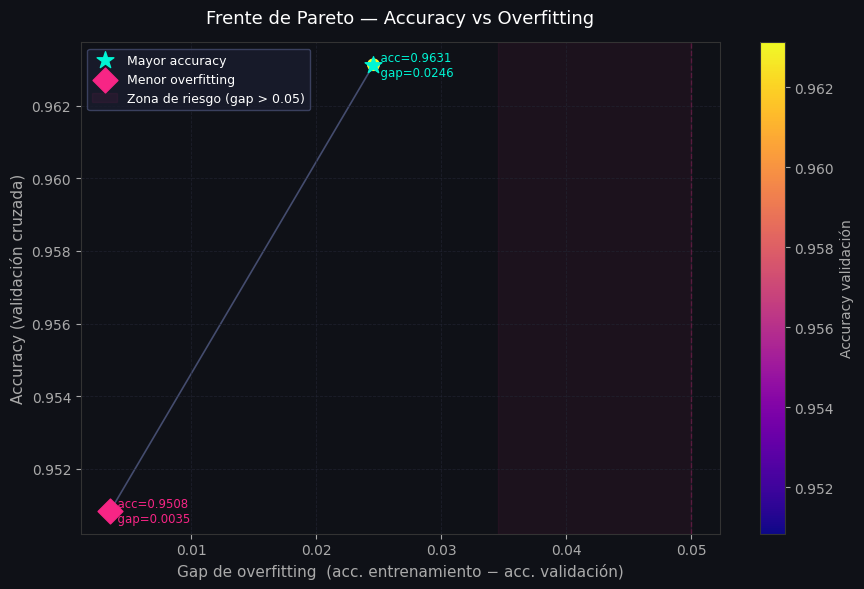

In [3]:
#Visualizacion del frente de Pareto

import matplotlib.pyplot as plt
import numpy as np

accuracies = [-s.objectives[0] for s in pareto_front]
gaps       = [s.objectives[1]  for s in pareto_front]

idx_mejor_acc = int(np.argmax(accuracies))
idx_menor_gap = int(np.argmin(gaps))

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# Línea que conecta el frente (ordenado por gap)
orden = np.argsort(gaps)
x_ord = [gaps[i]       for i in orden]
y_ord = [accuracies[i] for i in orden]
ax.plot(x_ord, y_ord, color="#444c6e", linewidth=1.2, zorder=1)

# Puntos del frente coloreados por accuracy
scatter = ax.scatter(
    gaps,
    accuracies,
    c=accuracies,
    cmap="plasma",
    s=80,
    zorder=2,
    edgecolors="#ffffff22",
    linewidths=0.5
)

# Destacar extremos
ax.scatter(gaps[idx_mejor_acc], accuracies[idx_mejor_acc],
           s=160, color="#00f5d4", zorder=3, label="Mayor accuracy", marker="*")
ax.scatter(gaps[idx_menor_gap], accuracies[idx_menor_gap],
           s=160, color="#f72585", zorder=3, label="Menor overfitting", marker="D")

# Anotaciones
ax.annotate(
    f"  acc={accuracies[idx_mejor_acc]:.4f}\n  gap={gaps[idx_mejor_acc]:.4f}",
    xy=(gaps[idx_mejor_acc], accuracies[idx_mejor_acc]),
    color="#00f5d4", fontsize=8.5, va="center"
)
ax.annotate(
    f"  acc={accuracies[idx_menor_gap]:.4f}\n  gap={gaps[idx_menor_gap]:.4f}",
    xy=(gaps[idx_menor_gap], accuracies[idx_menor_gap]),
    color="#f72585", fontsize=8.5, va="center"
)

# Zona de overfitting (referencia visual)
ax.axvspan(0.05, max(gaps) + 0.01, alpha=0.06, color="#f72585", label="Zona de riesgo (gap > 0.05)")
ax.axvline(x=0.05, color="#f7258540", linewidth=1, linestyle="--")

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Accuracy validación", color="#aaaaaa", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="#aaaaaa")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaaaa")
cbar.outline.set_edgecolor("#333333")

# Estilos
ax.set_xlabel("Gap de overfitting  (acc. entrenamiento − acc. validación)", color="#aaaaaa", fontsize=11)
ax.set_ylabel("Accuracy (validación cruzada)",                              color="#aaaaaa", fontsize=11)
ax.set_title("Frente de Pareto — Accuracy vs Overfitting",                 color="#ffffff", fontsize=13, pad=14)

ax.tick_params(colors="#aaaaaa")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

ax.legend(facecolor="#1a1d2e", edgecolor="#444c6e", labelcolor="#ffffff", fontsize=9)
ax.grid(color="#222533", linestyle="--", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

La zona rosada en el gráfico es un detalle extra: marca visualmente a partir de qué gap empieza a ser preocupante el overfitting, ayudando a tomar la decisión de qué solución del frente elegir. 